### Column Breakdown

artist_name: The name of the artist

track_name: The name of the song

release_date: Year song was released

genre: The categorical genre of this song

lyrics: The pre-tokenized lyrics of this song. Disclaimer: note that as this is real-world data, lyrical content is often obscene. 

len:  The number of words in the lyrics of this song

dating: A score from 0 to 1 expressing how likely it is that this song’s lyrics have something to do with dating.

violence: A score from 0 to 1 expressing how likely it is that this song’s lyrics have something to do with violence.

world/life: A score from 0 to 1 expressing how likely it is that this song’s lyrics have something to do with the world or life in general terms.

night/time: A score from 0 to 1 expressing how likely it is that this song’s lyrics have something to do night-life or time.

shake the audience: A score from 0 to 1 expressing how likely it is that this song’s lyrics have something to do with provocative feeling.

family/gospel: A score from 0 to 1 expressing how likely it is that this song’s lyrics have something to do with family-oriented content or the gospel.

romantic: A score from 0 to 1 expressing how likely it is that this song’s lyrics have something to do with romantic feeling.

communication: A score from 0 to 1 expressing how likely it is that this song’s lyrics have something to do with communication (either in romantic terms or otherwise).

obscene: A score from 0 to 1 expressing how likely it is that this song’s lyrics have something to do with obscene content (money, rockstar-lifestyle, etc).

music: A score from 0 to 1 expressing how likely it is that this song’s lyrics have something to do with music (music about music, basically).

movement/places: A score from 0 to 1 expressing how likely it is that this song’s lyrics have something to do with movement or various locations.

light/visual perceptions: A score from 0 to 1 expressing how likely it is that this song’s lyrics have something to do with the sun or other physical weather-related patterns.

family/spiritual: A score from 0 to 1 expressing how likely it is that this song’s lyrics have something to do with the importance of family or spirituality.

sadness: A score from 0 to 1 expressing how likely it is that this song’s lyrics have something to do with the importance of family or spirituality.

feelings: A score from 0 to 1 expressing how likely it is that this song’s lyrics have something to do with emotions, either positive or negative.

topic: The categorical label of lyrical content

age: A score from 0 to 1 expressing how “old” a song is from our perspective. 1 being the oldest, and 0 being the newest.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns


In [76]:
#read-in
data = pd.read_csv('/Users/sa12/Documents/Repositories/MusicReccomendation/MusicRecommendation/Data/train.csv')

In [77]:
data.tail()

,Unnamed: 0,artist_name,track_name,release_date,genre,lyrics,len,dating,violence,world/life,...,communication,obscene,music,movement/places,light/visual perceptions,family/spiritual,sadness,feelings,topic,age
28357,82447,mack 10,10 million ways,2019,hip hop,cause fuck leave scar tick tock clock come kno...,78,0.001350,0.001350,0.001350,...,0.001350,0.391651,0.001350,0.435089,0.001350,0.001350,0.065664,0.001350,obscene,0.014286
28358,82448,m.o.p.,ante up (robbin hoodz theory),2019,hip hop,minks things chain ring braclets yap fame come...,67,0.001284,0.001284,0.035338,...,0.203889,0.318910,0.058152,0.134955,0.001284,0.001284,0.001284,0.001284,obscene,0.014286
28359,82449,nine,whutcha want?,2019,hip hop,get ban get ban stick crack relax plan attack ...,77,0.001504,0.154302,0.168988,...,0.001504,0.356685,0.001504,0.068684,0.001504,0.001504,0.001504,0.001504,obscene,0.014286
28360,82450,will smith,switch,2019,hip hop,check check yeah yeah hear thing call switch g...,67,0.001196,0.001196,0.001196,...,0.001196,0.492434,0.103614,0.001196,0.202659,0.001196,0.001196,0.001196,obscene,0.014286
28361,82451,jeezy,r.i.p.,2019,hip hop,remix killer alive remix thriller trap bitch s...,83,0.001012,0.075202,0.001012,...,0.001012,0.754444,0.046284,0.001012,0.001012,0.001012,0.001012,0.033995,obscene,0.014286


After examining both head and tail, the unnamed column seems to be a non-linear list of decending numbers; possibly an old index. Regardless, this column is unnecessary and can be dropped in the cleaning process. Another column that stands out is track_name. This unique identifer can be dropped in the cleaning process because we want a generalized model.

In [83]:
#drop Unnamed
data = data.drop(columns='Unnamed: 0')
data.describe()

,release_date,len,dating,violence,world/life,night/time,shake the audience,family/gospel,romantic,communication,obscene,music,movement/places,light/visual perceptions,family/spiritual,sadness,feelings,age
count,28362.000000,28362.000000,28362.000000,28362.000000,28362.000000,28362.000000,28362.000000,28362.000000,28362.000000,28362.000000,28362.000000,28362.000000,28362.000000,28362.000000,28362.000000,28362.000000,28362.000000,28362.000000
mean,1990.239652,73.030534,0.021110,0.118371,0.120984,0.057356,0.017418,0.017045,0.048676,0.076651,0.097185,0.060067,0.047417,0.049008,0.024155,0.129402,0.030995,0.425148
std,18.486997,41.831605,0.052366,0.178658,0.172216,0.111892,0.040658,0.041968,0.106071,0.109497,0.181314,0.123346,0.091559,0.089553,0.051032,0.181149,0.071656,0.264100
min,1950.000000,1.000000,0.000291,0.000284,0.000291,0.000289,0.000284,0.000289,0.000284,0.000291,0.000289,0.000289,0.000284,0.000284,0.000284,0.000284,0.000289,0.014286
25%,1975.000000,42.000000,0.000923,0.001120,0.001170,0.001032,0.000993,0.000923,0.000975,0.001144,0.001053,0.000975,0.000993,0.000993,0.000957,0.001144,0.000993,0.185714
50%,1991.000000,63.000000,0.001462,0.002506,0.006579,0.001949,0.001595,0.001504,0.001754,0.002632,0.001815,0.001815,0.001645,0.001815,0.001645,0.005263,0.001754,0.414286
75%,2007.000000,93.000000,0.004049,0.192538,0.197854,0.065778,0.009989,0.004785,0.042304,0.132111,0.088799,0.055109,0.054373,0.064302,0.025515,0.235115,0.032617,0.642857
max,2019.000000,199.000000,0.647706,0.981781,0.962105,0.973684,0.497463,0.545303,0.940789,0.645829,0.992298,0.956938,0.638021,0.667782,0.618073,0.981424,0.958810,1.000000


In [5]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 28362 entries, 0 to 28361
Data columns (total 23 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   artist_name               28362 non-null  object 
 1   track_name                28362 non-null  object 
 2   release_date              28362 non-null  int64  
 3   genre                     28362 non-null  object 
 4   lyrics                    28362 non-null  object 
 5   len                       28362 non-null  int64  
 6   dating                    28362 non-null  float64
 7   violence                  28362 non-null  float64
 8   world/life                28362 non-null  float64
 9   night/time                28362 non-null  float64
 10  shake the audience        28362 non-null  float64
 11  family/gospel             28362 non-null  float64
 12  romantic                  28362 non-null  float64
 13  communication             28362 non-null  float64
 14  obscen

So one of the first things that stands out to me is that we have a column for age and a column for release_date. In theory, these columns should be identical. Lets plot this out and see.

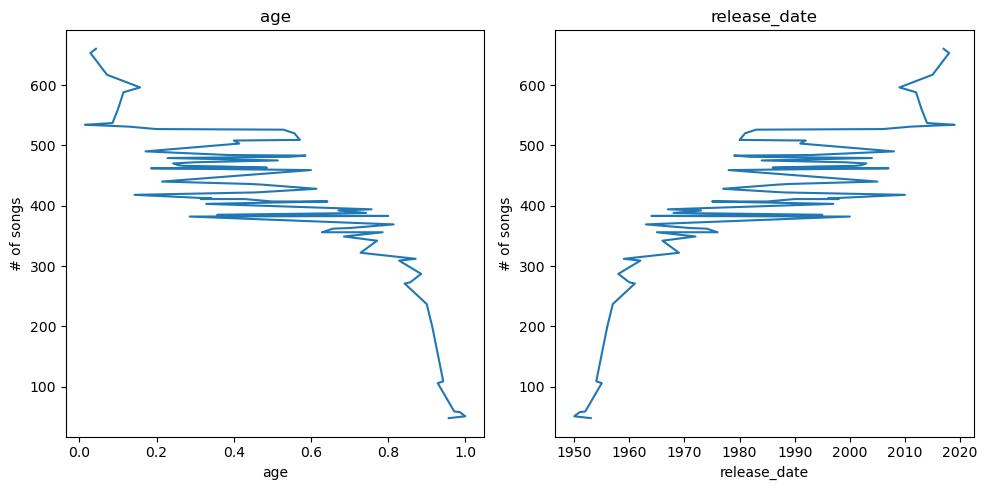

In [78]:
plt.figure(figsize=(10, 5))# Adjust figure size as needed
plt.subplot(1, 2, 1)  # First subplot (1 row, 2 columns, 1st position)
plt.plot(data['age'].value_counts())
plt.xlabel('age')
plt.ylabel('# of songs')
plt.title('age')
plt.subplot(1, 2, 2)  # Second subplot (1 row, 2 columns, 2nd position)
plt.plot(data['release_date'].value_counts())
plt.xlabel('release_date')
plt.ylabel('# of songs')
plt.title('release_date')
plt.tight_layout() # Adjusts subplot params for a tight layout
plt.show()

The graphs mirror each other, meaning one of these columns should be dropped in the cleaning process. Because of the standardization of the age column, that should be the retained column in our model. However, for interpretability I will use the release_date column to perform analysis with.

### Univariate Analysis

My first steps are to isolate and evaluate the quantitative variables in our data sets. Our first steps are to remove catagorical data from the dataset and evaluate the quantity of each feature in each the dataset. th

In [85]:
lyrical_data = data.drop(columns=['artist_name','track_name','release_date','genre', 'lyrics','len','topic'])

ValueError: Columns must be same length as key

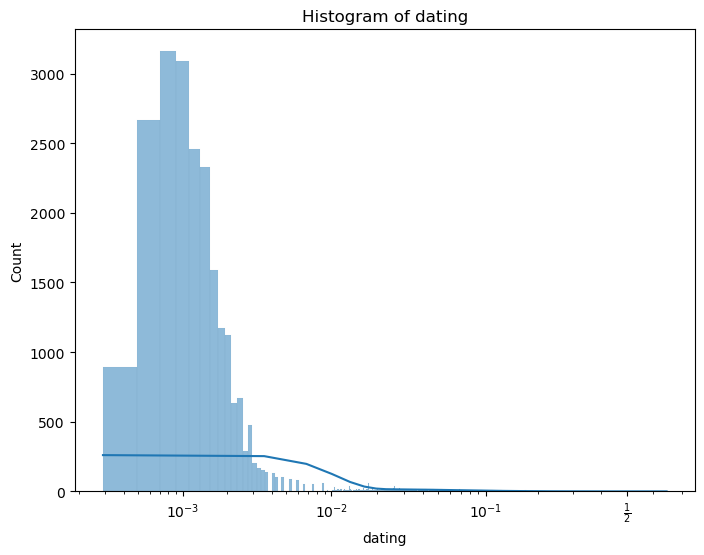

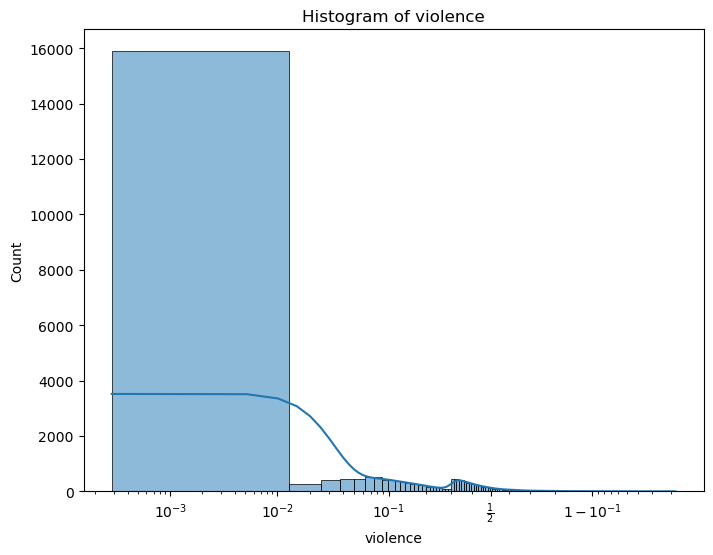

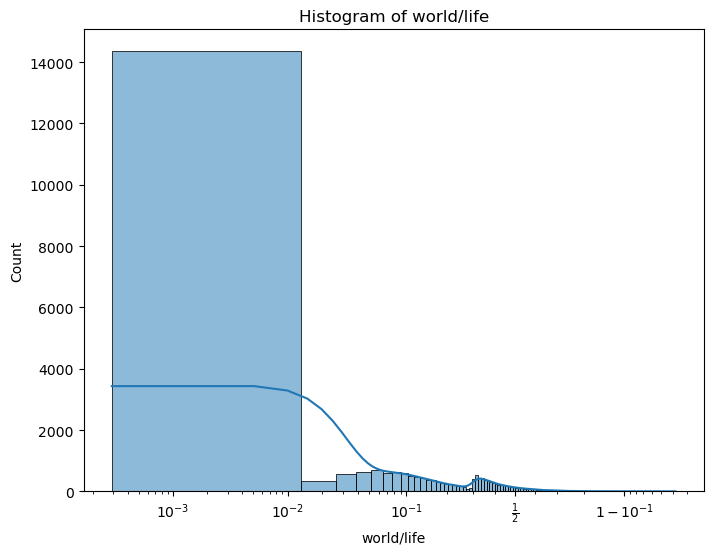

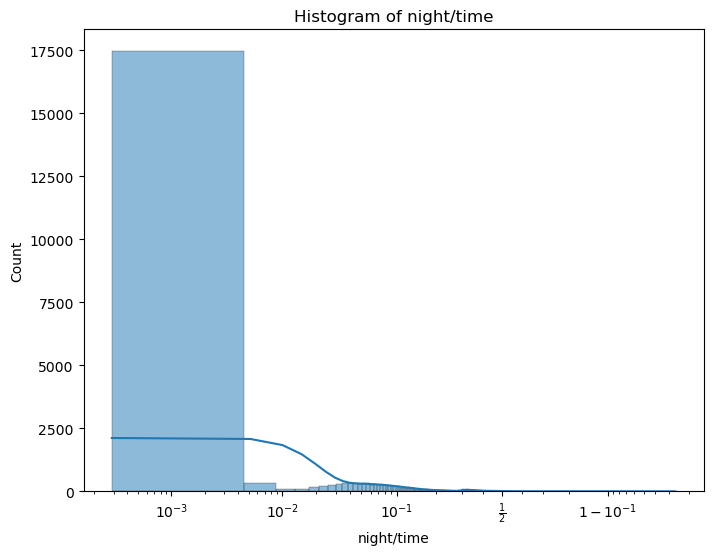

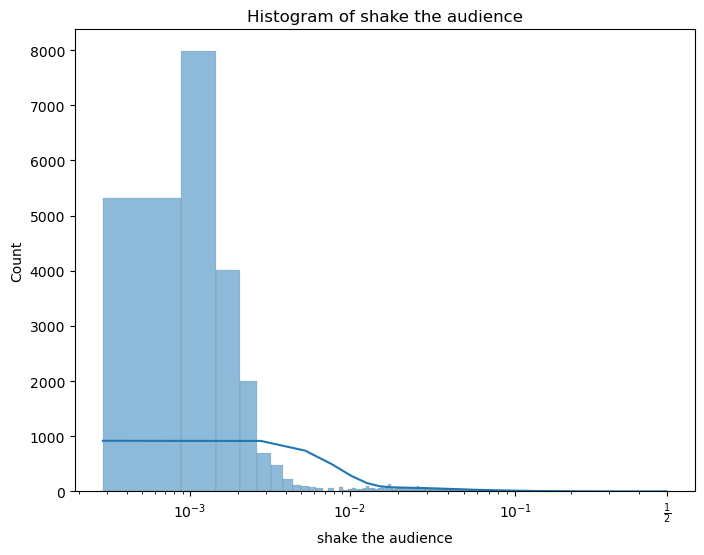

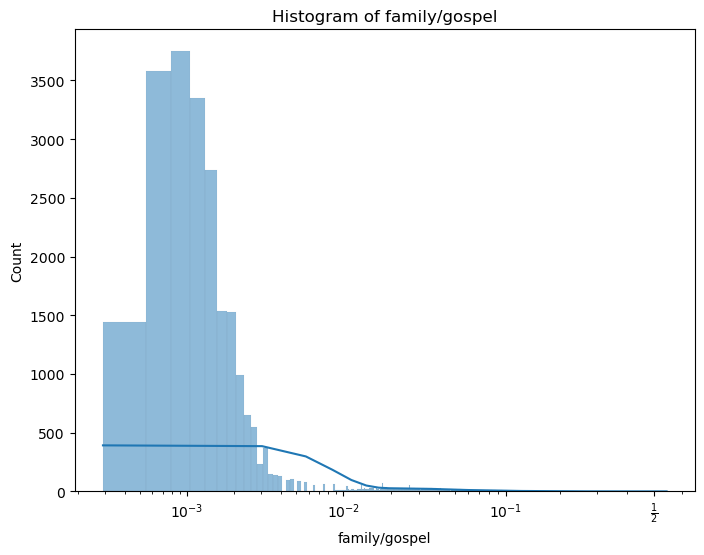

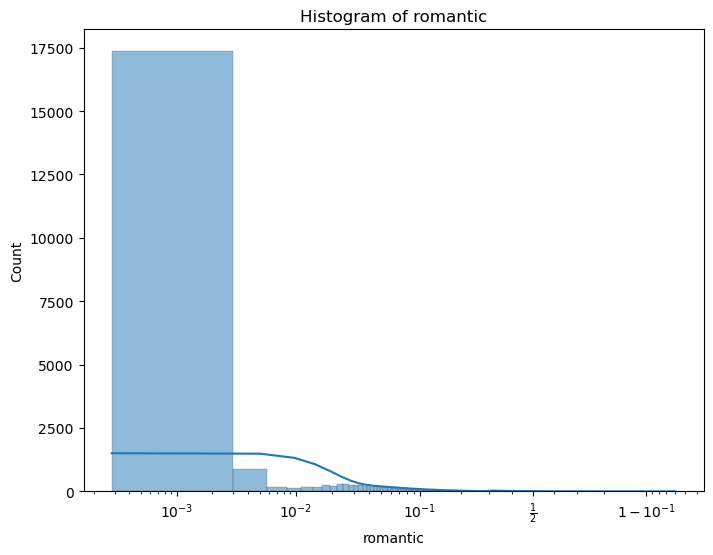

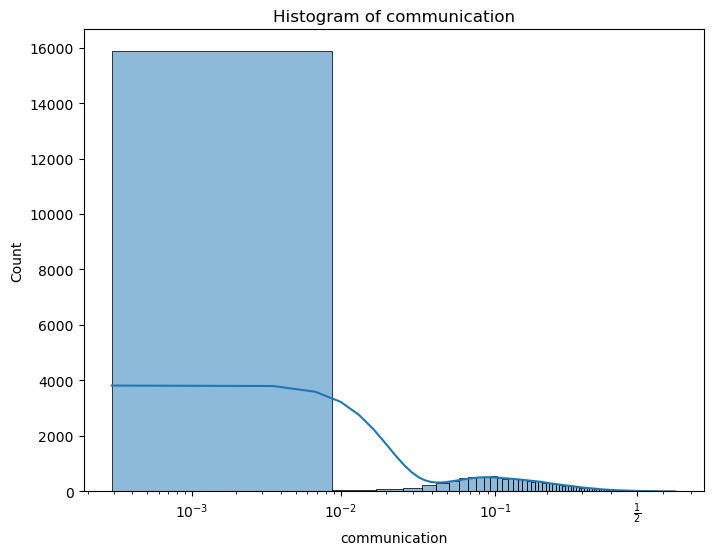

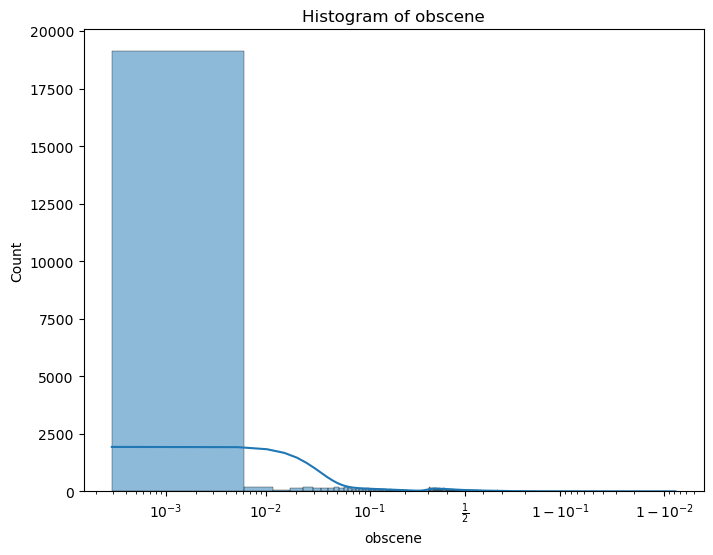

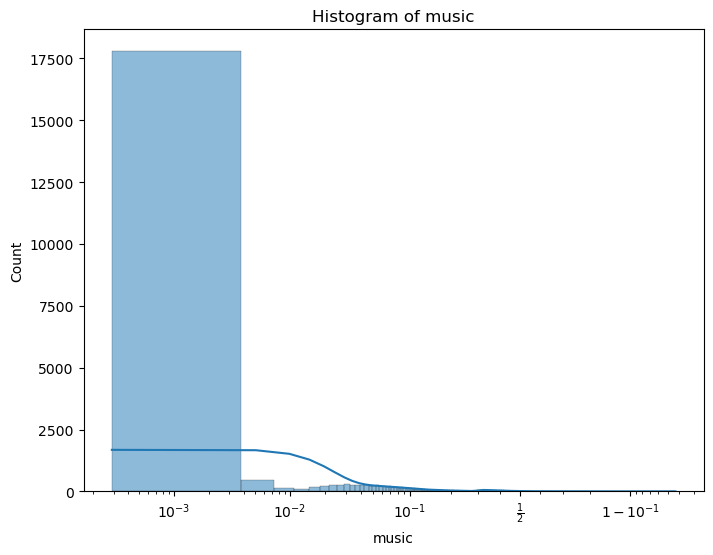

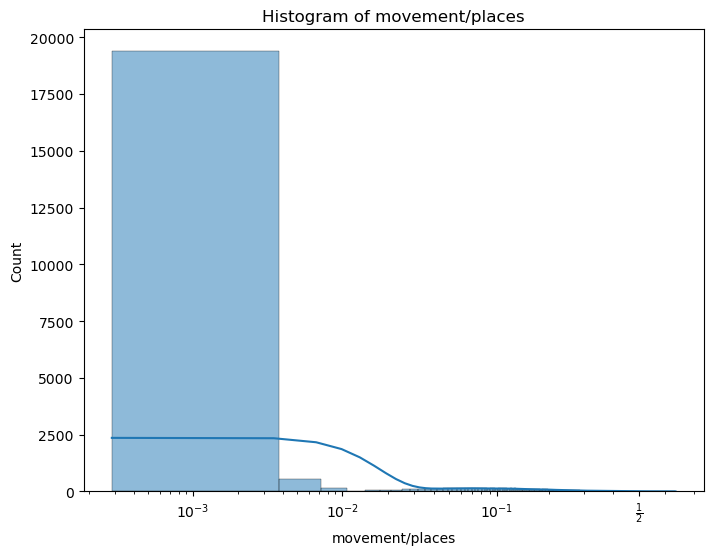

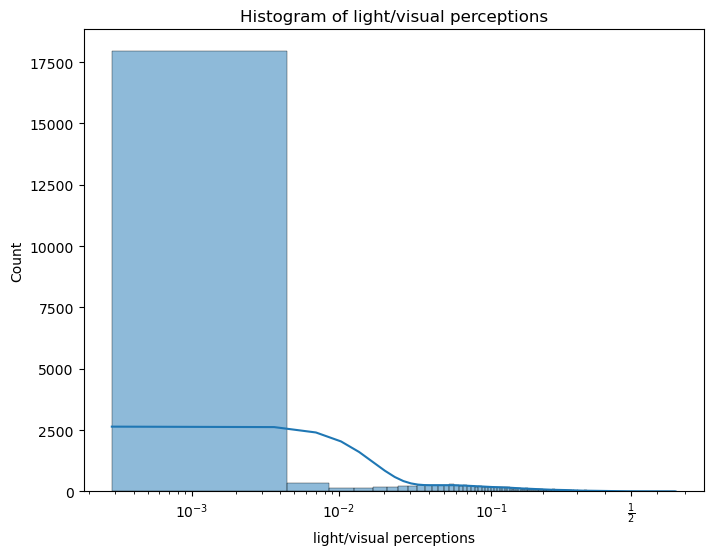

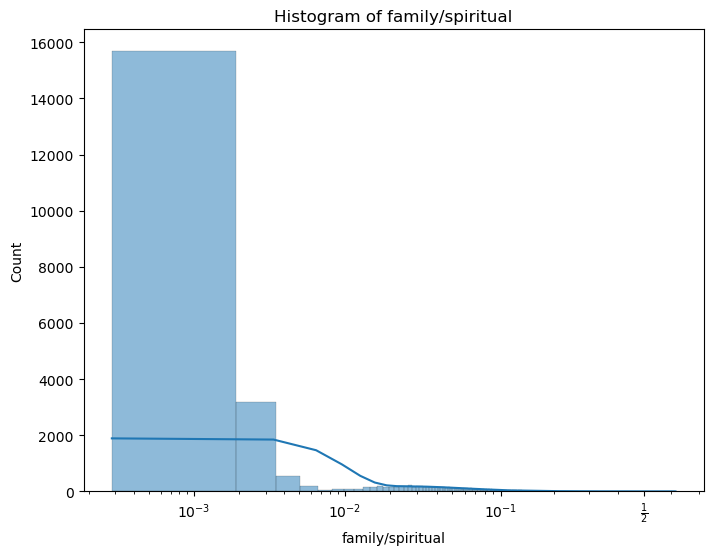

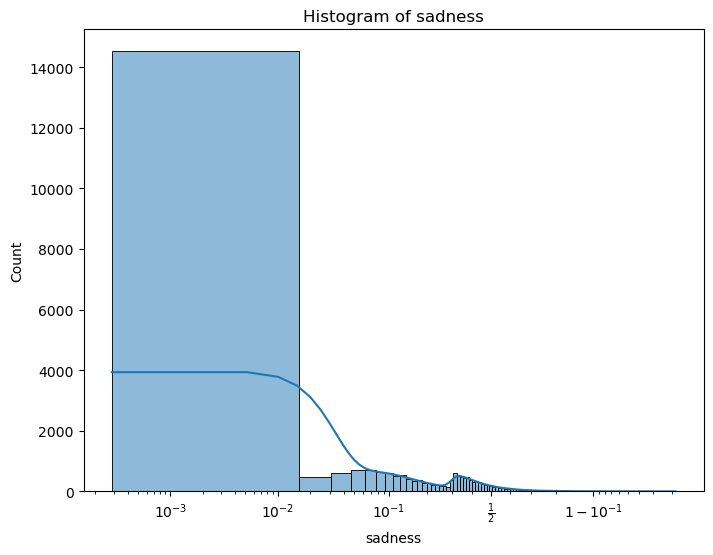

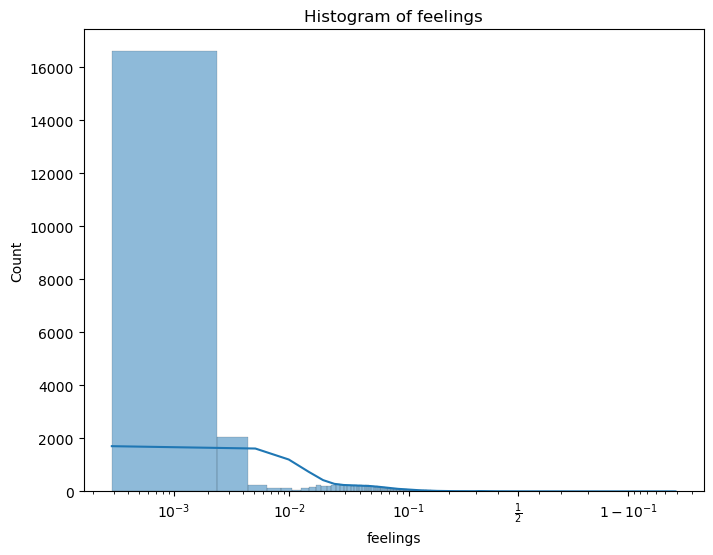

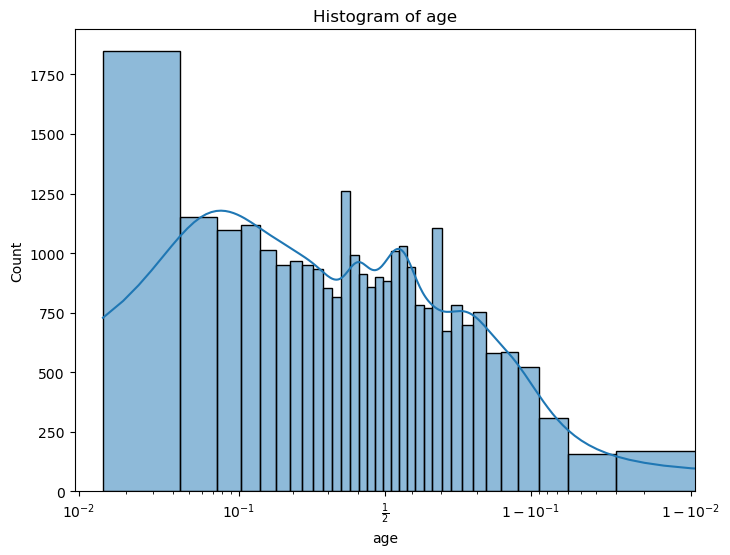

In [86]:
for feature in lyrical_data:
    plt.figure(figsize=(8, 6))
    sns.histplot(data=lyrical_data, x=feature, kde=True)
    plt.xlabel(feature)
    plt.ylabel('Count')
    plt.xscale('logit')
    plt.title(f'Histogram of {feature}')
    plt.show()

The logarithmically scaled charts show a large concentration of values in the area around zero. This makes sense in a wider perspective, most songs will focus on a few topics and be near 0 in all other catagories. 

In [9]:
#seperate catagorical columns minus track_name & artist_name(too many to plot)
cata = ['genre','len','topic']
cata_data = data[cata]

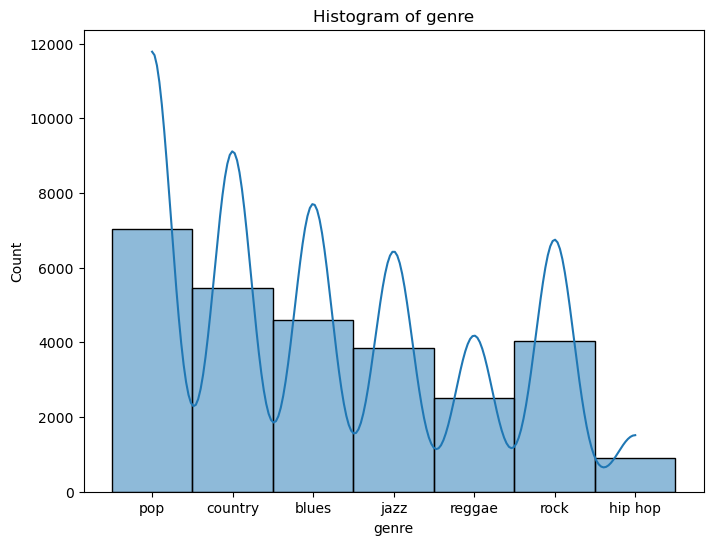

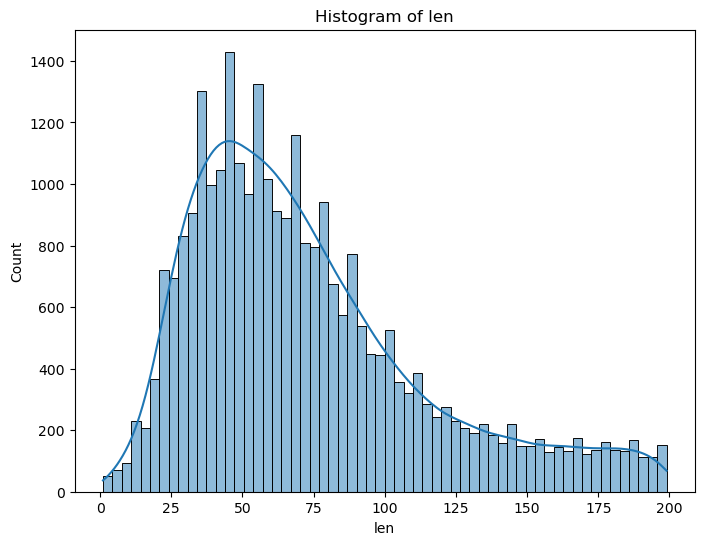

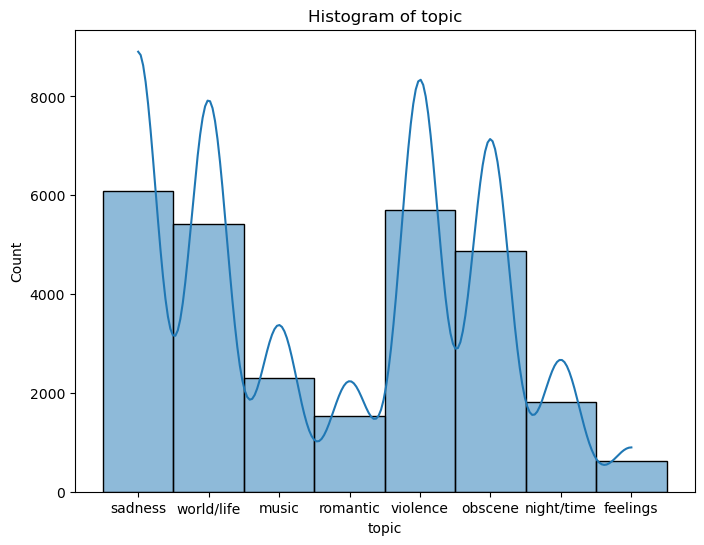

In [10]:
for feature in cata_data:
    plt.figure(figsize=(8, 6))
    sns.histplot(data=cata_data, x=feature, kde=True)
    plt.xlabel(feature)
    plt.ylabel('Count')
    plt.title(f'Histogram of {feature}')
    plt.show()

At the end of our univariate analysis, the only thing that is clear is we are dealing with a lot of numerical columns with mostly small values.

## Bivariate Analysis

I will start by using a pairplot to see if any relationships between columns exist. I will then visualize this data using a heatmap. I also believe it would be a good idea to visualize the mean of each 'lyrical' column against some of our catagorical columns in a similar fashion.

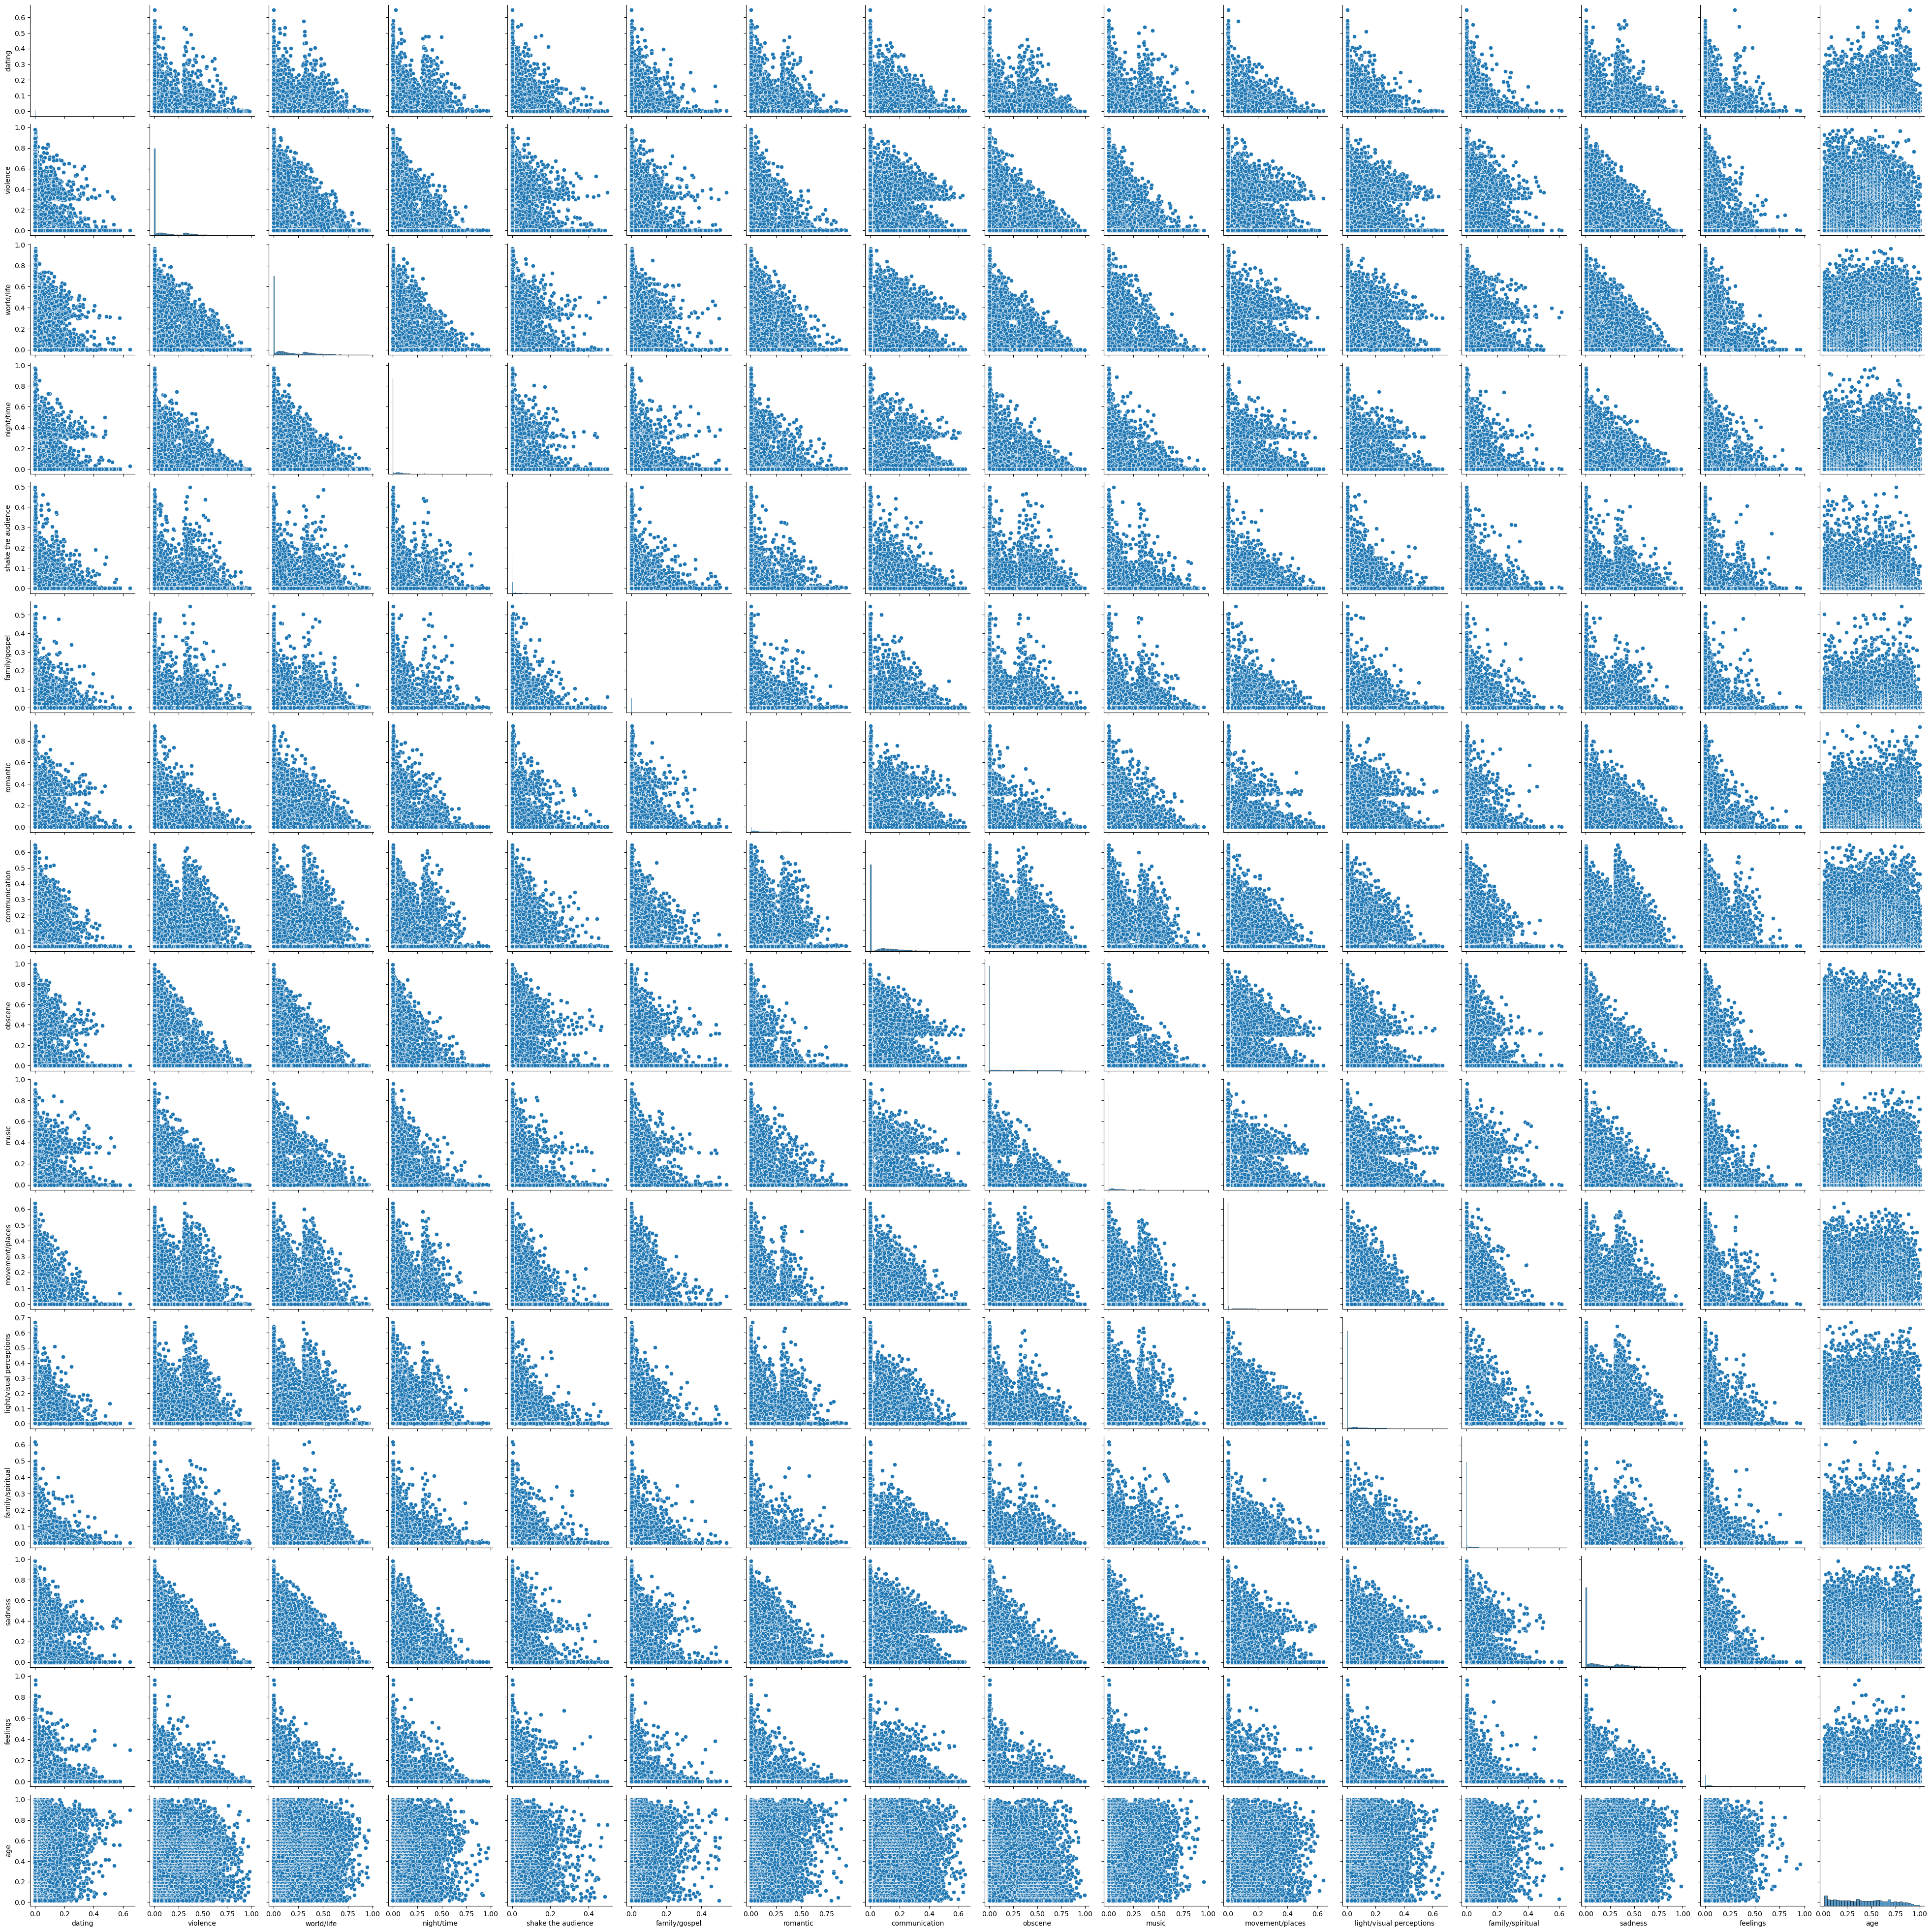

In [11]:
sns.pairplot(lyrical_data)

Not much to discerne from this pairplot, but there does seem to be interesting splits in some of the data. Most catagories have a linear correlation, as one value increases the other decreases, but we see some of the distributions have a secondary mode. This would indicate that some lyrical content columns are closer connected than others.

<Axes: >

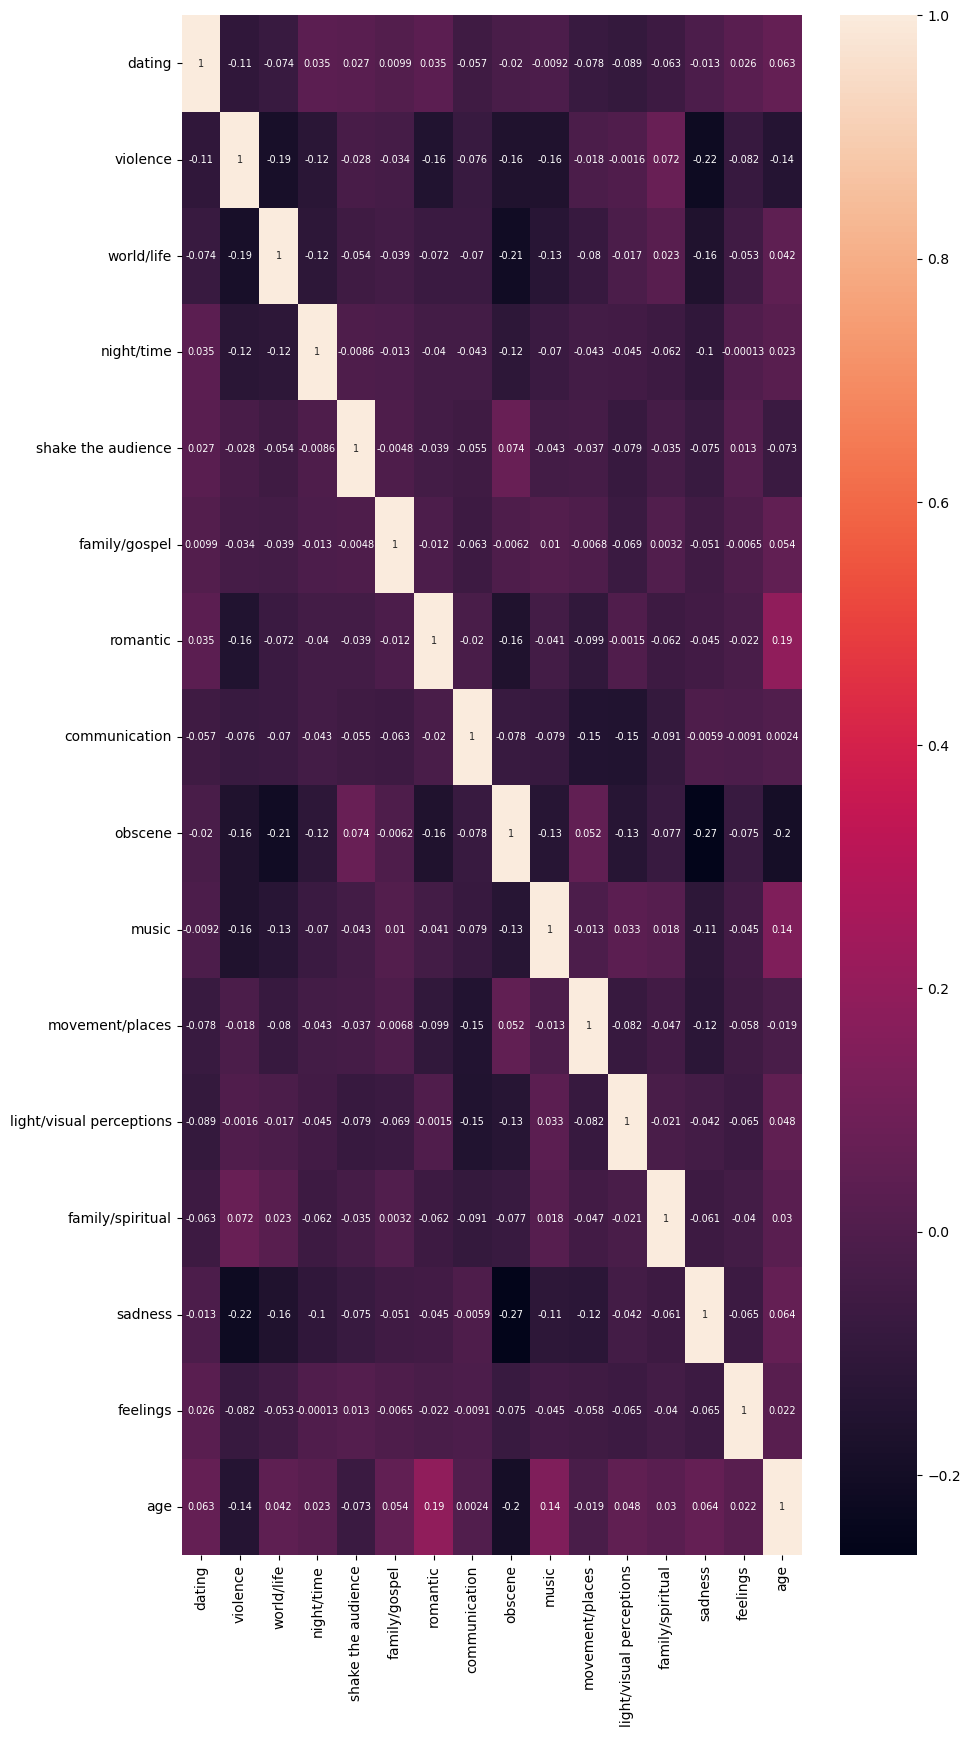

In [12]:
plt.figure(figsize=(10,20))
sns.heatmap(lyrical_data.corr(), annot=True, annot_kws={'size':7})

This heatmap showwing correlation directly relates to our pairplot. The values with the highest negative correlations will be 

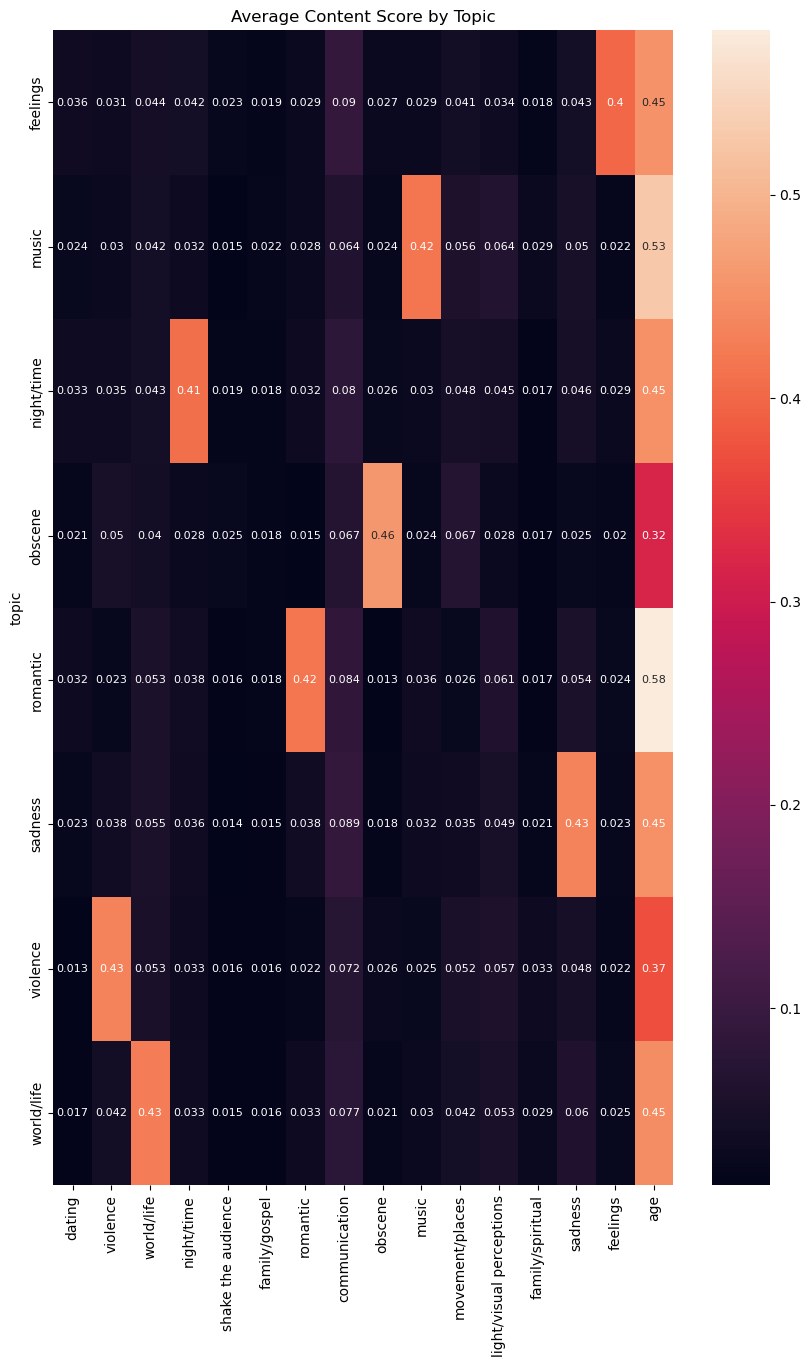

In [5]:
topic_data = data.drop(columns=['artist_name','track_name','release_date','genre', 'lyrics','len'])
group_topic_data = topic_data.groupby('topic').mean()
plt.figure(figsize=(10,15))
sns.heatmap(group_topic_data, annot=True, annot_kws={'size':8})
plt.title('Average Content Score by Topic')
plt.show()

JACKPOT! There is a very strong coorelation between the topic column and the lyrical content columns. The mean values in each content column are much higher in song with topics (of the same name). What this means is that our data will be clustered in dimensional space without need for the topic column to catagorize. It may be dropped in the cleaning process.

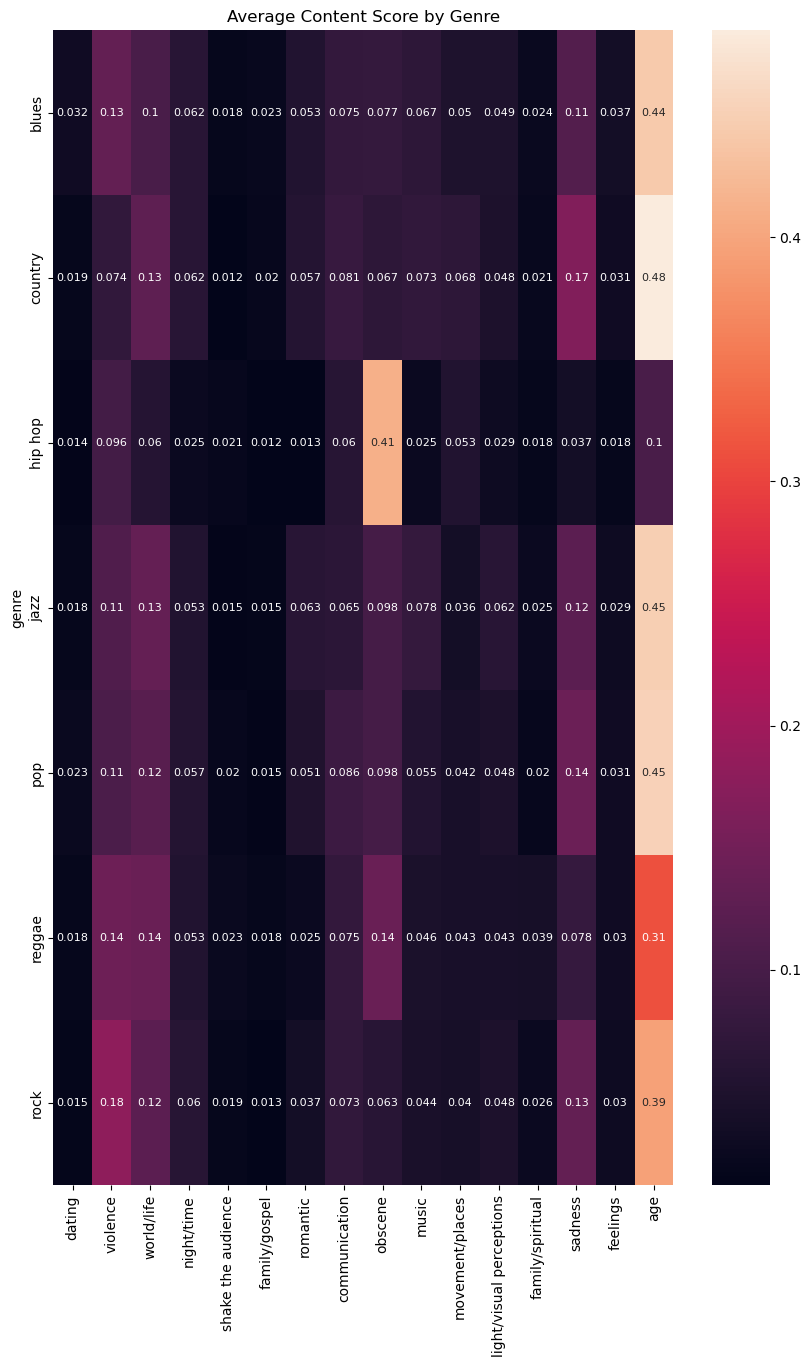

In [6]:
genre_data = data.drop(columns=['artist_name','track_name','release_date','topic', 'lyrics','len'])
group_genre_data = genre_data.groupby('genre').mean()
plt.figure(figsize=(10,15))
sns.heatmap(group_genre_data, annot=True, annot_kws={'size':8})
plt.title('Average Content Score by Genre')
plt.show()

In [74]:
group_genre_data.values

array([[0.03177385, 0.13355751, 0.10322981, 0.06245724, 0.01832401,
        0.02250373, 0.05251713, 0.07450073, 0.07673735, 0.06731193,
        0.04983311, 0.04882993, 0.0244641 , 0.11346711, 0.03724222,
        0.44261196],
       [0.01851184, 0.07416717, 0.12785043, 0.06239359, 0.01164069,
        0.02025939, 0.05748318, 0.08105639, 0.06730017, 0.0726657 ,
        0.06760849, 0.0477971 , 0.02106985, 0.16595258, 0.03063741,
        0.48487194],
       [0.01409938, 0.09594425, 0.0596071 , 0.025385  , 0.02064507,
        0.01184002, 0.01261057, 0.05978029, 0.41119936, 0.02525993,
        0.05265316, 0.02868478, 0.01818201, 0.03658872, 0.01759098,
        0.10350822],
       [0.01827992, 0.10990501, 0.13406793, 0.05320014, 0.01468463,
        0.01539242, 0.06264879, 0.06536143, 0.09752875, 0.07771899,
        0.03599816, 0.06227119, 0.02506158, 0.12409886, 0.02908587,
        0.44949086],
       [0.02302014, 0.10519997, 0.11908335, 0.05657237, 0.01950202,
        0.01477093, 0.05140958, 

This heatmap does not show correlation, it shows the mean score of each value that falls under that genre.

<Axes: xlabel='topic', ylabel='len'>

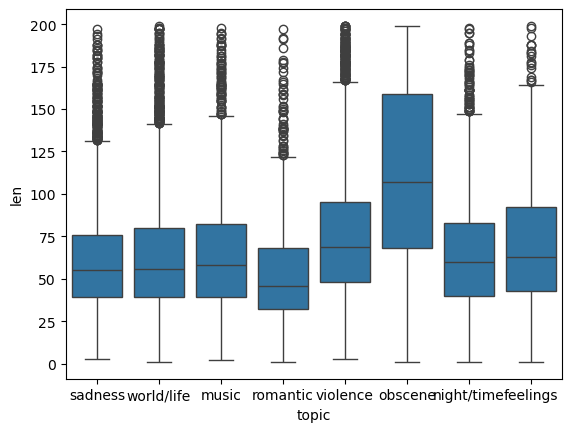

In [9]:
sns.boxplot(data, x='topic', y='len')

<Axes: xlabel='genre', ylabel='len'>

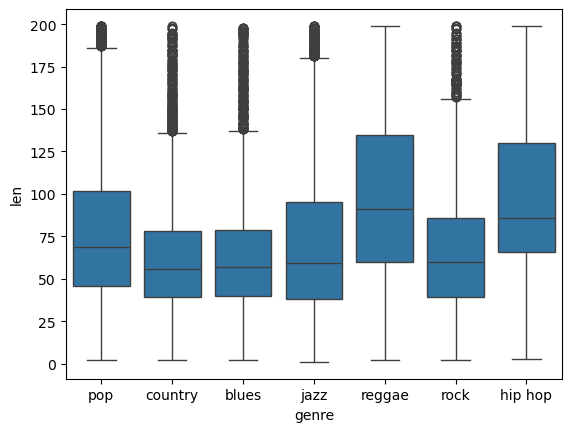

In [10]:
sns.boxplot(data, x='genre', y='len')

We see a pretty uniform distribution of medians across all genres and topics when comparing the length. There was also a very normal distribution of values when we performed our univariate analysis. This indicates that our len column can be dropped in the cleaning process because it has no predictive qualities.

<Axes: xlabel='genre', ylabel='count'>

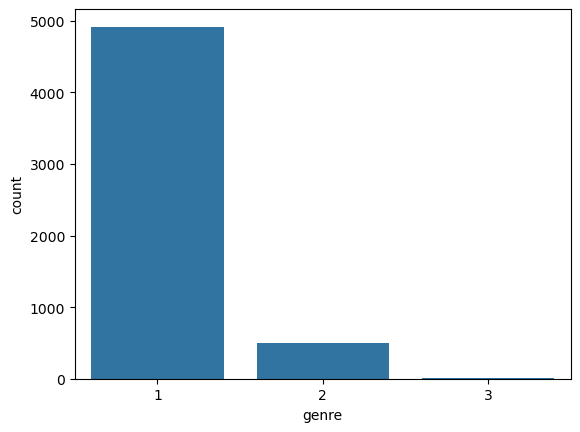

In [62]:
artist_groups = data.groupby('artist_name')['genre'].nunique()
sns.barplot(artist_groups.value_counts())


<Axes: xlabel='topic', ylabel='count'>

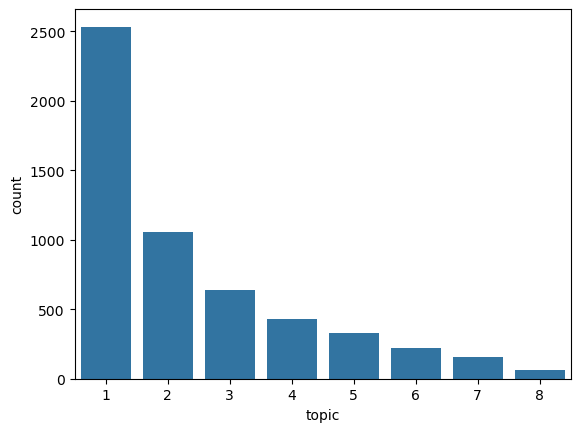

In [63]:
artist_topic = data.groupby('artist_name')['topic'].nunique()
sns.barplot(artist_topic.value_counts())

Examining artist name and the relationships to the genre and topic columns. In relation to genre, around 90% of artists stuck to a single genre. When looking at topic, there is greater variety by artists but most artists are still under 3 topics. Analyzing these charts in the context of the data above leads me to believe that our model will be able to properly identify the topic column based on the data in the lyrical content score columns. Furthermore, if I can show that 

### Multivariate Analysis

In [89]:
artist_data = data.drop(columns=['track_name','release_date','genre', 'lyrics','len','topic'])
plt.legend()
sns.pairplot(data=artist_data, hue='artist_name')

/opt/anaconda3/lib/python3.12/site-packages/seaborn/utils.py:61: UserWarning: Glyph 24373 (\N{CJK UNIFIED IDEOGRAPH-5F35}) missing from current font.
  fig.canvas.draw()
/opt/anaconda3/lib/python3.12/site-packages/seaborn/utils.py:61: UserWarning: Glyph 38706 (\N{CJK UNIFIED IDEOGRAPH-9732}) missing from current font.
  fig.canvas.draw()
/opt/anaconda3/lib/python3.12/site-packages/seaborn/utils.py:61: UserWarning: Glyph 24429 (\N{CJK UNIFIED IDEOGRAPH-5F6D}) missing from current font.
  fig.canvas.draw()
/opt/anaconda3/lib/python3.12/site-packages/seaborn/utils.py:61: UserWarning: Glyph 23478 (\N{CJK UNIFIED IDEOGRAPH-5BB6}) missing from current font.
  fig.canvas.draw()
/opt/anaconda3/lib/python3.12/site-packages/seaborn/utils.py:61: UserWarning: Glyph 40599 (\N{CJK UNIFIED IDEOGRAPH-9E97}) missing from current font.
  fig.canvas.draw()
/opt/anaconda3/lib/python3.12/site-packages/seaborn/axisgrid.py:198: UserWarning: Glyph 24373 (\N{CJK UNIFIED IDEOGRAPH-5F35}) missing from current fo

/opt/anaconda3/lib/python3.12/site-packages/IPython/core/events.py:82: UserWarning: Glyph 24373 (\N{CJK UNIFIED IDEOGRAPH-5F35}) missing from current font.
  func(*args, **kwargs)
/opt/anaconda3/lib/python3.12/site-packages/IPython/core/events.py:82: UserWarning: Glyph 38706 (\N{CJK UNIFIED IDEOGRAPH-9732}) missing from current font.
  func(*args, **kwargs)
/opt/anaconda3/lib/python3.12/site-packages/IPython/core/events.py:82: UserWarning: Glyph 24429 (\N{CJK UNIFIED IDEOGRAPH-5F6D}) missing from current font.
  func(*args, **kwargs)
/opt/anaconda3/lib/python3.12/site-packages/IPython/core/events.py:82: UserWarning: Glyph 23478 (\N{CJK UNIFIED IDEOGRAPH-5BB6}) missing from current font.
  func(*args, **kwargs)
/opt/anaconda3/lib/python3.12/site-packages/IPython/core/events.py:82: UserWarning: Glyph 40599 (\N{CJK UNIFIED IDEOGRAPH-9E97}) missing from current font.
  func(*args, **kwargs)
/opt/anaconda3/lib/python3.12/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 24373

ValueError: Image size of 4331x113662 pixels is too large. It must be less than 2^16 in each direction.

<Figure size 4368.88x4000 with 272 Axes>

if not, we can drop the artist name column in the cleaning process.

In [64]:
# create a new column called "Age_labels" in this dataframe that assigns 5 quartile-cut bin labels using the "Age" column

data["age_labels"] = pd.qcut(data["age"], 5)
data["date_labels"] = pd.qcut(data["release_date"], 5)
data

,artist_name,track_name,release_date,genre,lyrics,len,dating,violence,world/life,night/time,...,music,movement/places,light/visual perceptions,family/spiritual,sadness,feelings,topic,age,age_labels,date_labels
0,mukesh,mohabbat bhi jhoothi,1950,pop,hold time feel break feel untrue convince spea...,95,0.000598,0.063746,0.000598,0.000598,...,0.039288,0.000598,0.000598,0.000598,0.380299,0.117175,sadness,1.000000,"(0.686, 1.0]","(1949.999, 1972.0]"
1,frankie laine,i believe,1950,pop,believe drop rain fall grow believe darkest ni...,51,0.035537,0.096777,0.443435,0.001284,...,0.118034,0.001284,0.212681,0.051124,0.001284,0.001284,world/life,1.000000,"(0.686, 1.0]","(1949.999, 1972.0]"
2,johnnie ray,cry,1950,pop,sweetheart send letter goodbye secret feel bet...,24,0.002770,0.002770,0.002770,0.002770,...,0.323794,0.002770,0.002770,0.002770,0.002770,0.225422,music,1.000000,"(0.686, 1.0]","(1949.999, 1972.0]"
3,pérez prado,patricia,1950,pop,kiss lips want stroll charm mambo chacha merin...,54,0.048249,0.001548,0.001548,0.001548,...,0.001548,0.129250,0.001548,0.001548,0.225889,0.001548,romantic,1.000000,"(0.686, 1.0]","(1949.999, 1972.0]"
4,giorgos papadopoulos,apopse eida oneiro,1950,pop,till darling till matter know till dream live ...,48,0.001350,0.001350,0.417772,0.001350,...,0.001350,0.001350,0.001350,0.029755,0.068800,0.001350,romantic,1.000000,"(0.686, 1.0]","(1949.999, 1972.0]"
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
28357,mack 10,10 million ways,2019,hip hop,cause fuck leave scar tick tock clock come kno...,78,0.001350,0.001350,0.001350,0.001350,...,0.001350,0.435089,0.001350,0.001350,0.065664,0.001350,obscene,0.014286,"(0.0133, 0.157]","(2009.0, 2019.0]"
28358,m.o.p.,ante up (robbin hoodz theory),2019,hip hop,minks things chain ring braclets yap fame come...,67,0.001284,0.001284,0.035338,0.001284,...,0.058152,0.134955,0.001284,0.001284,0.001284,0.001284,obscene,0.014286,"(0.0133, 0.157]","(2009.0, 2019.0]"
28359,nine,whutcha want?,2019,hip hop,get ban get ban stick crack relax plan attack ...,77,0.001504,0.154302,0.168988,0.001504,...,0.001504,0.068684,0.001504,0.001504,0.001504,0.001504,obscene,0.014286,"(0.0133, 0.157]","(2009.0, 2019.0]"
28360,will smith,switch,2019,hip hop,check check yeah yeah hear thing call switch g...,67,0.001196,0.001196,0.001196,0.001196,...,0.103614,0.001196,0.202659,0.001196,0.001196,0.001196,obscene,0.014286,"(0.0133, 0.157]","(2009.0, 2019.0]"


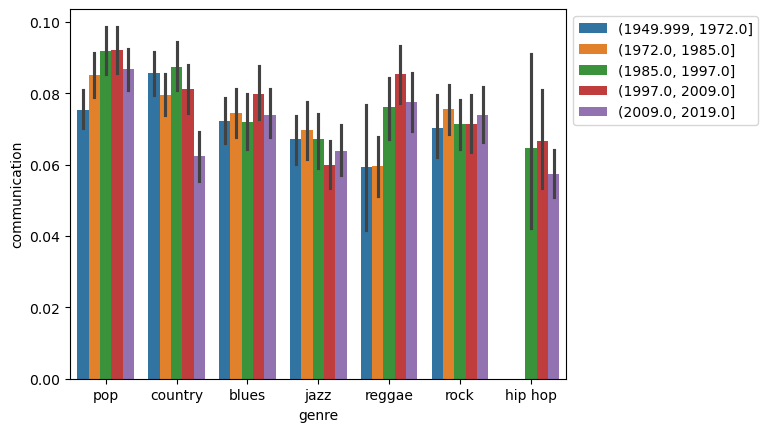

In [66]:
sns.barplot(data, x='genre', y='communication', hue='date_labels')
plt.legend(bbox_to_anchor=(1,1))
plt.show()

ValueError: Could not interpret value `date_labels` for `hue`. An entry with this name does not appear in `data`.

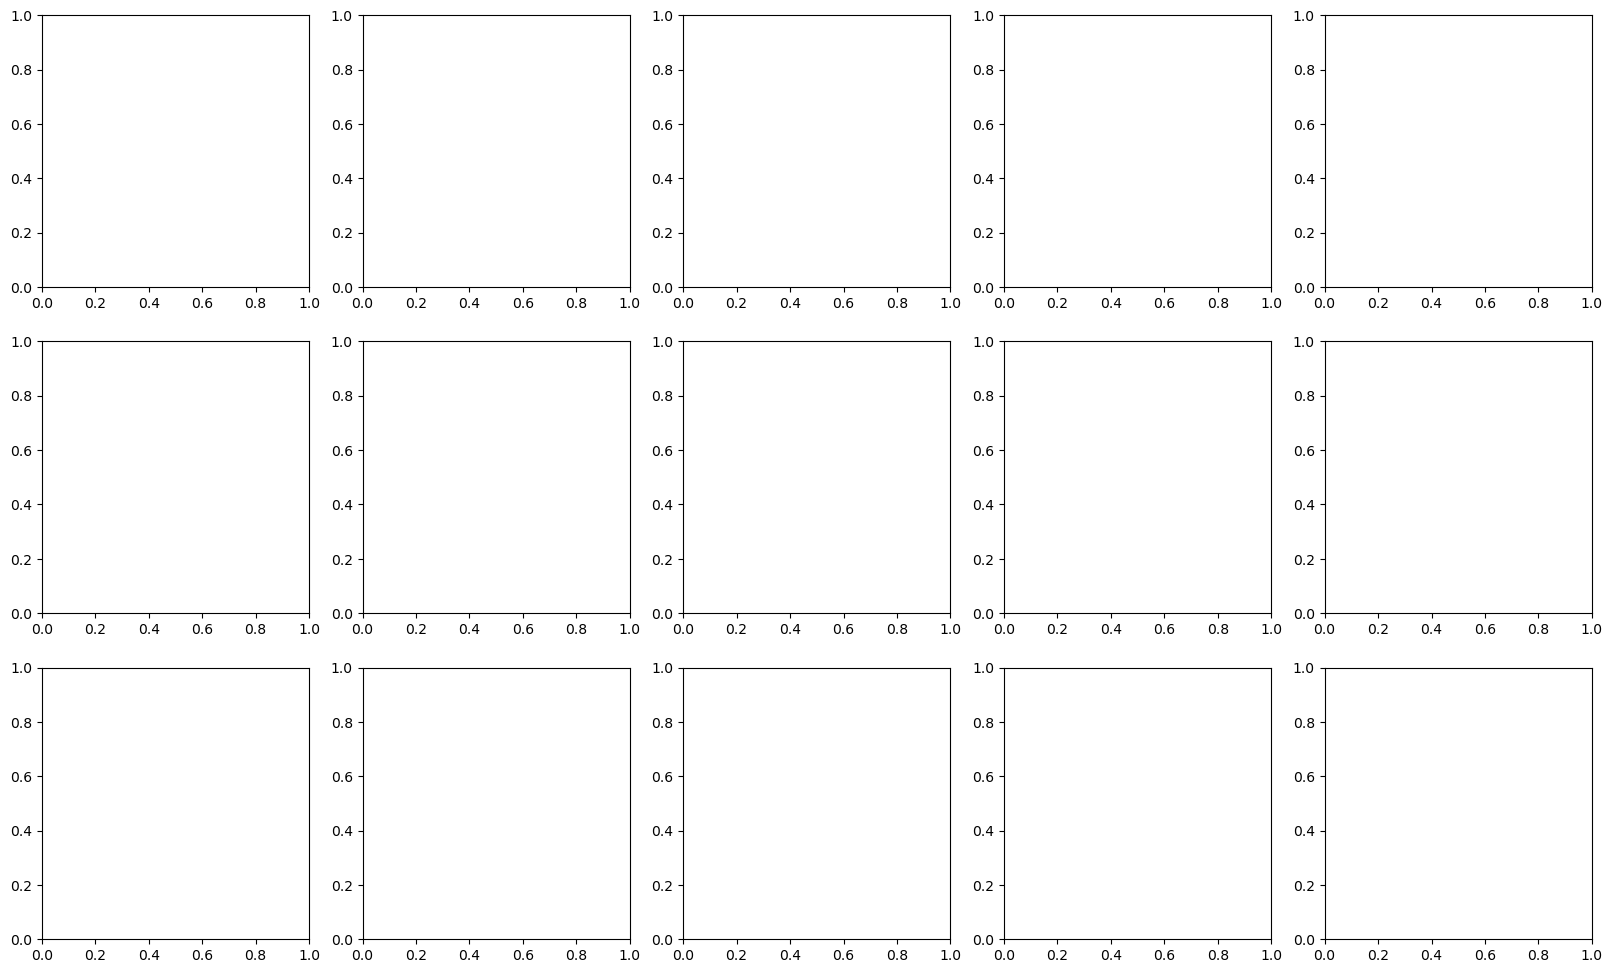

In [90]:
# List of lyrical features to compare across different music genres
features = [
    'dating', 'violence', 'world/life', 'night/time', 'shake the audience', 'family/gospel',
    'romantic', 'communication', 'obscene', 'music', 'movement/places', 'light/visual perceptions',
    'family/spiritual', 'sadness', 'feelings',
]
# Create a 3x5 grid of subplots to visualize each feature
fig, axes = plt.subplots(3, 5, figsize=(20, 12))  # 3 rows x 5 columns layout
# Loop through each feature and create a barplot by genre
for idx, feature in enumerate(features):
    row = idx // 5  # Determine row index in subplot grid
    col = idx % 5   # Determine column index in subplot grid
    ax = axes[row, col]
    # Plot the average value of the feature per genre using seaborn barplot
    sns.barplot(data=data, x='genre', y=feature, hue='date_labels', ax=ax, errorbar=None)
    ax.set_title(f'{feature} by Genre', fontsize=10)  # Set subplot title
    ax.set_xlabel('')  # Remove x-axis label for cleaner layout
    ax.get_legend().remove()
    ax.tick_params(axis='x', rotation=45)
# Adjust spacing between subplots to prevent overlapping
plt.legend(title='Age Group', bbox_to_anchor=(.5,-.5), fontsize = 11)
plt.tight_layout()
plt.show()

In [48]:
sns

artist_name
johnny cash        190
ella fitzgerald    188
dean martin        146
willie nelson      131
george jones       107
                  ... 
stigmato inc         1
plej                 1
slow train soul      1
oi va voi            1
$uicideboy$          1
Name: count, Length: 5424, dtype: int64